<h4>定义 Определение</h4>

In [372]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import floor
import csv

In [373]:
type = {"Iris-virginica":0,"Iris-versicolor":1,"Iris-setosa":2}#将类型变为数字 Преобразование типов в числа
name = ["Iris-virginica","Iris-versicolor","Iris-setosa"]#将数字变为类型 Преобразование чисел в типы

<h4>读取文件并把向量数字化 Чтение файла и векторизация данных</h4>

In [374]:
file = 'iris.csv'
df = pd.read_csv(file, encoding='utf-8')
array = df.to_numpy()
for j in range(len(array)):
    array[j][4] = type[array[j][4]]

<h4>提取初始以及目标向量 Извлечение начальных и целевых векторов</h4>

In [375]:
X = array[:, :4]
Y = array[:, 4]
num_INP = len(array)

#min-max归一化避免非线性模型数值溢出
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X = (X - X_min) / (X_max - X_min + 1e-8)

<h4>可视化（AI生成） Визуализация(AI-gen)</h4>

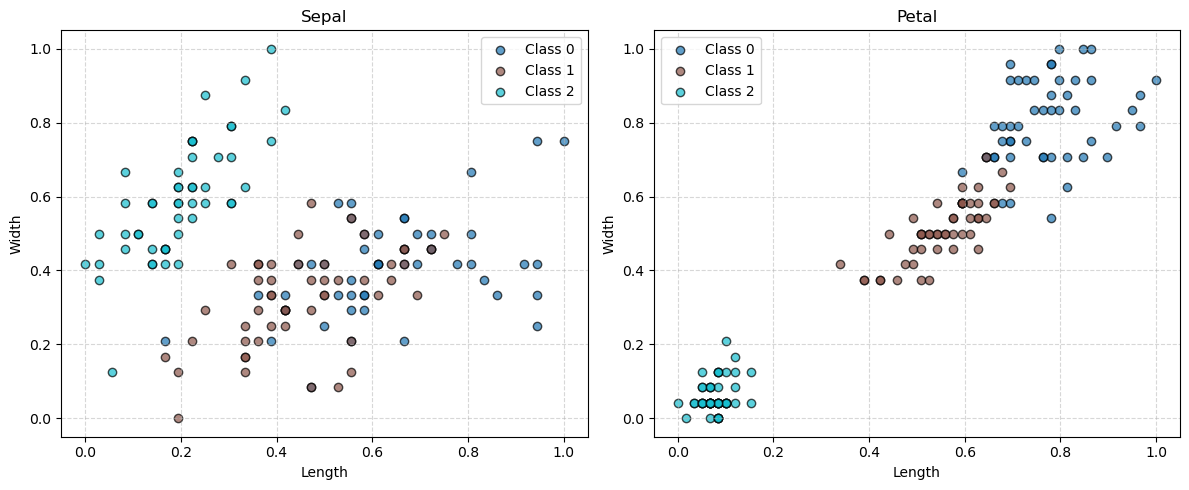

In [376]:
unique_labels = np.unique(Y)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for label, color in zip(unique_labels, colors):
    mask = (Y == label)
    ax1.scatter(X[mask, 0], X[mask, 1], c=[color], label=f'Class {label}', edgecolors='k', alpha=0.7)
ax1.set_xlabel('Length')
ax1.set_ylabel('Width')
ax1.set_title('Sepal')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

for label, color in zip(unique_labels, colors):
    mask = (Y == label)
    ax2.scatter(X[mask, 2], X[mask, 3], c=[color], label=f'Class {label}', edgecolors='k', alpha=0.7)
ax2.set_xlabel('Length')
ax2.set_ylabel('Width')
ax2.set_title('Petal')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<h4>在下面定义容许误差ε，最大许可训练次数maxTime以及训练率α</h4>

In [377]:
epsilon = 0.05*num_INP#定义容许误差 Определение допустимой погрешности
maxTime = int(1E4)
alpha = 1E-5

<h4>多项式类</h4>

In [378]:
class polinomVector:
    def __init__(self, p, q):#初始化以及变量定义 p为多项式次数，q为向量维度
        self.item=[]
        self.p = p
        self.q = q
        self.constant = 0
        self.item = np.zeros((p, q), dtype=float)

    def save(self, filename):#保存
        flat_coeff = self.item.flatten().tolist()
        str_coeff = [str(x) for x in flat_coeff]
        with open(filename, 'w') as f:
            f.write(' '.join(str_coeff) + ' ' + str(self.constant))

    def load(self, filename):#读取
        with open(filename, 'r') as f:
            nums = list(map(float, f.readline().split()))
        expected_len = self.p * self.q + 1
        if len(nums) != expected_len:
            raise ValueError(f"数据数量错误：期望 {expected_len}，实际 {len(nums)}")
        self.item = np.array(nums[:self.p*self.q]).reshape(self.p, self.q)
        self.constant = nums[-1]

    def func(self, inpvec):#幂函数多项式模型
        out = self.constant
        if len(inpvec) != self.q:
            raise Exception("维度错误")
        powers = np.array([inpvec[i] ** (j+1) for i in range(self.q) for j in range(self.p)]).reshape(self.q, self.p).T
        out = self.constant + np.sum(powers * self.item)
        return out
    
    def err(self, inpvec):
        if len(inpvec) != self.q+1:
            raise Exception("维度错误")
        return (self.func(inpvec[:(len(inpvec)-1)])-inpvec[len(inpvec)-1])**2
    
    def total_err(self):#总误差 Общая погрешность
        out=0
        for i in range(num_INP):
            out+=(self.err([X[i][0],X[i][1],X[i][2],X[i][3],Y[i]]))
        return out

    def train(self, alpha, maxtimes, epsilon):
        global times
        gradient = np.zeros((self.p, self.q), dtype=float)
        consta = 0
        for index in range(maxtimes):
            for j in range(num_INP):
                temp = 2*(self.func(X[j])-Y[j])
                consta += temp
                for i in range(self.p):
                    for k in range(self.q):
                        gradient[i][k] += temp*X[j][k]**(i+1)
            self.item += -alpha * gradient
            self.constant += -alpha * consta
            times += 1
            if  self.total_err() < epsilon:
                break       



coeff = polinomVector(2,4)
print(coeff.item) 


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]]


<h4>选择数据来源，输入0重新输入，输入其他数字使用保存的参数 Выберите источник данных, введите 0 для повторного ввода, введите другую цифру для использования сохраненных параметров</h4>

In [379]:
mode = int(input())#0为重置，1为继续训练，其他数字为跳过训练 0 - сброс, 1 - продолжение обучения, другие числа - пропуск обучения
if not mode:
    pass
else:
     coeff.load("nonlinear2.txt")
                
print(coeff.item)

[[-0.67429839  0.43468945  1.105203   -1.678403  ]
 [ 0.75034113  0.24477941 -2.2813879  -0.00868772]]


<h4>训练及模型 Обучение и модель</h4>

In [380]:
def roughlyEnoughInt(inp):#四舍五入 Округление
    if inp-floor(inp) <0.5:
        if inp<0:
            return 0
        else:
            return floor(inp)
    else:
        if floor(inp)+1>2:
            return 2
        else:
            return floor(inp)+1

def predict(inpvec):#结果模型 Итоговая модель
    return roughlyEnoughInt(coeff.func(inpvec))

print("训练前总误差")#Русский: Общая погрешность до обучения
beginerr=coeff.total_err()
print(beginerr)
if mode == 1 or (mode ==0):
    times = 0
    coeff.train(alpha,maxTime,epsilon)
    print("训练后总误差")#Русский: Общая погрешность после обучения
    enderr = coeff.total_err()
    print(enderr)
    print("训练次数")#Русский:
    print(times)
    print("平均每次训练减小误差")#Русский:
    print((beginerr-enderr)/times)
else:
    print("未进行训练")#Русский: Обучение не проводилось
coeff.save("nonlinear2.txt")

训练前总误差
7.047271525485336
训练后总误差
7.045855568707165
训练次数
1
平均每次训练减小误差
0.0014159567781710791


<h4>测试模型 Тест Моделя</h4>

In [381]:
output_file = 'predictions.csv' # 输出文件 Выходной файл
predicted_names = []
outX1 = []
outX2 = []
outX3 = []
outX4 = []
for i in range(num_INP):
    outX1.append(X[i][0])
    outX2.append(X[i][1])
    outX3.append(X[i][2])
    outX4.append(X[i][3])
    pred_num = predict(X[i])          # 返回数字标签 0,1,2 Возвращает числовые метки 0,1,2
    pred_name = name[pred_num]          # 转换为品种名称 Преобразование в названия сортов
    predicted_names.append(pred_name)

# 写入CSV Запись в CSV
with open(output_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width','Species'])         # 表头 Заголовок
    index = 0
    for name_label in predicted_names:
        writer.writerow([outX1[index],outX2[index],outX3[index],outX4[index],name_label])
        index += 1

print(f"预测完成，结果已保存至 {output_file}")#Русский: Прогноз завершен, результат сохранен в {output_file}

预测完成，结果已保存至 predictions.csv


<h4>准确度检查 Проверка точности</h4>

In [382]:
Trues = 0
Faults = 0
for i in range(num_INP):
    if type[predicted_names[i]] == Y[i]:
        Trues += 1
    else:
        Faults += 1

precision = Trues/(Trues+Faults)
print("准确率：")#Русский: Точность:
print(f"准确率：{precision*100:.2f}%") 
print("正确数：")#Русский: Количество правильных:
print(Trues)
print("错误数：")#Русский: Количество ошибок:
print(Faults)

准确率：
准确率：98.00%
正确数：
147
错误数：
3
